Note: Decided to run the replication code in the colab envirnment due to gpu restrictions on our peronal computers. Therefore, we also had to reduce some paremeters (as specified in step 1) during the replication in order to achive similar results to the paper.

In [58]:
import os, re, random
import pandas as pd
from sklearn.datasets import fetch_openml
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
)
import torch
import numpy as np


In [59]:
# ---------- GLOBAl CONFIGS -----------
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
random.seed(42)

# Setting DEVICE to be dynamic (uses GPU if available, else CPU)
if torch.cuda.is_available():
    torch.set_default_device("cuda")
    DEVICE = torch.device("cuda")
    print("Using GPU")
else:
    torch.set_default_device("cpu")
    DEVICE = torch.device("cpu")
    print("Using CPU - GPU is currently unavilable")

# --- Values Taken from Paper Specifications ---
MODEL_NAME = "distilgpt2"   # stays no matter the dataset chosen
MAX_LEN = 256               # not explicitly specified but is assumed
BATCH_SIZE = 32             # (32 is specified in the paper - stays no matter the dataset chosen)
EPOCHS = 10                 # (50 is specified in the paper - stays no matter the dataset chosen)
N_SAMPLES = 2000            # (5000 specified in the paper for the adult dataset) # rows we want in our synthetic dataset

# --- Loading the Two Chosen Datasets ---
# -- Comment out the one not in use --
# - Adult Dataset -
# DATASET_NAME = "adult"
# LABEL_ORIG = "class"
# LABEL_NEW = "income"
# CSV_OUT = "data/synthetic_adult_predllm_mini.csv"

# - Bank Dataset -
DATASET_NAME = "Bank"
CSV_OUT = "data/synthetic_bank_predllm_mini.csv"

print(f" --- Loading Dataset: {DATASET_NAME} --- ")
chosen_dataset = fetch_openml(name="bank-marketing", as_frame=True)
df = chosen_dataset.frame.copy()


# --- Improvement: Label Detection ---
candidate_labels = ["y", "class", "Class", "label", "Label", "target", "Target"]
# match case-insensitively but return the original column name
cols_lower = {c.lower(): c for c in df.columns}
LABEL = None
for cand in candidate_labels:
    if cand.lower() in cols_lower:
        LABEL = cols_lower[cand.lower()]
        break
if LABEL is None:
    LABEL = df.columns[-1]
    print(f"Warning: Could not detect label column automatically, defaulting to last column: {LABEL}")

LABEL_COL = LABEL
df = df.dropna().reset_index(drop=True)

print("Detected LABEL column:", LABEL)
print("Label values:", df[LABEL].astype(str).value_counts().head(10))

df = df.sample(n=min(2000, len(df)), random_state=42).reset_index(drop=True) # keeps a smaller subset (computationally easier on our laptops)

FEATURES = [c for c in df.columns if c != LABEL]    # creates a list of column names but excludes the target LABEL value, this is bc we are trying to predict that label

print(df.columns)


#improvement section
# ---------- Improvement: Cheap Schema Constraints (Improves Realism) ----------
# from pred_llm_mini_no_finetune import sample_feature_value

REAL_UNIQUES = {}
REAL_NUM_STATS = {}

for c in FEATURES:
    if df[c].dtype == "object":
        REAL_UNIQUES[c] = set(df[c].astype(str).str.strip().str.lower().unique().tolist())           # normalizing the strings to lower case and stripping whitespace
    else:
        col_num = pd.to_numeric(df[c], errors="coerce")         # convert to numeric, coerce errors to NaN (this helps handle non-numeric entries)
        REAL_NUM_STATS[c] = {
            "min": float(col_num.min()),    # real min
            "max": float(col_num.max()),
        }

def enforce_schema(feats: dict) -> dict:
    """Helper function to sample a numeric feature value within real min/max range
    generated values to validate real schema (cheap & improves evaluation)."""
    out = dict(feats)        # make a copy to avoid modifying original

    for c in FEATURES:
        v = out.get(c, None)     # get the generated value for the column

        # categorical
        if c in REAL_UNIQUES:
            if v is None:
                out[c] = random.choice(df[c].astype(str).tolist())      # if no value generated, sample a real value
                continue
            vn = str(v).strip().lower()                                 # normalize generated value for comparison
            if vn not in REAL_UNIQUES[c]:
                out[c] = random.choice(df[c].astype(str).tolist())      # sample a real value if generated value not in real uniques
            else:
                matches = df[c].astype(str)
                match_list = matches[matches.str.strip().str.lower() == vn].tolist()
                out[c] = random.choice(match_list) if match_list else str(v).strip()

        # numeric
        else:
            stats = REAL_NUM_STATS[c]        # get the real stats for the column, this helps us clip the values so that they are realistic
            if v is None:
                out[c] = sample_feature_value(c)    # sample a real value if none generated
                continue
            try:
                x = float(str(v).strip())      # convert to float so that we can do min/max clipping
                x = max(stats["min"], min(stats["max"], x))   # clip - this helps keep the values realistic
                out[c] = x                  # assign the clipped value
            except Exception:
                out[c] = sample_feature_value(c)     # sample a real value if conversion fails

    return out       # output is expected to be categorial values as strings and numeric values as floats, now enforced to be realistic.


print(df.columns)

Using GPU
 --- Loading Dataset: Bank --- 
Detected LABEL column: Class
Label values: Class
1    39922
2     5289
Name: count, dtype: int64
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='object')
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name bank-marketing exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1461
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1558

  warn(warning_msg)


In [60]:
# STEP 1
# ---------- Serialization helpers: Fine-tune with Y last + Permute - learn p(Y｜X） ----------
def serialize_row(row: pd.Series, feature_order, label_col: str) -> str:
    ''' Used to help the model understand the data.
        The input data is currently a key value pair,
        but inorder for it to actually understand and process it, it converts it to string format.
    '''
    parts = []
    for col in feature_order:
        parts.append(f"{col} is {str(row[col]).strip()}")
    parts.append(f"{label_col} is {str(row[label_col]).strip()}")
    return ", ".join(parts)

def build_training_corpus(df: pd.DataFrame, features, label_col, permute_ratio=0.7):
    ''' Used to shuffle the order around of the passed in serialized string but
    makes sure that the LABEL value is always last.
        This helps with the training process
    '''
    texts = []
    for _, r in df.iterrows():
        texts.append(serialize_row(r, features, label_col))
        if random.random() < permute_ratio:
            fperm = features[:]
            random.shuffle(fperm)
            texts.append(serialize_row(r, fperm, label_col))
    return texts

print("Building training texts…")
train_texts = build_training_corpus(df, FEATURES, LABEL, permute_ratio=0.7)
print(train_texts)

# ---------- Tokenization + Training ----------
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

enc = tok(
    train_texts,
    padding=True,
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
)

class TxtDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.enc = encodings
    def __len__(self):
        return self.enc["input_ids"].shape[0]
    def __getitem__(self, i):
        return {
            "input_ids": self.enc["input_ids"][i],
            "attention_mask": self.enc["attention_mask"][i],
            "labels": self.enc["input_ids"][i],
        }

ds = TxtDataset(enc)

# --- Model Specifications ---
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.to(DEVICE)

# --- Training Specifications ---
# -- Described earlier in the code --
args = TrainingArguments(
    output_dir="runs/predllm-mini",
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=8,
    num_train_epochs=EPOCHS,
    learning_rate=5e-5,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    bf16=False,
    logging_steps=50,
    save_steps=5000,
    save_total_limit=1,
    report_to=[],
    no_cuda=not torch.cuda.is_available(),  # only disable CUDA if GPU isn't available
    dataloader_pin_memory=False,
    # use_mps_device=False,     # only needed if running on a mac
)

print("Initializing the trainer...")
trainer = Trainer(model=model, args=args, train_dataset=ds)   # initializes the trainer
print(trainer)

print("Fine-tuning (CPU/GPU - depending on which one is selected to run on)")
trainer.train()   # startes training
model = trainer.model
model.to(DEVICE)
model.eval()

print("Model is on device - ", next(model.parameters()).device)

# --- Saves Finetuning Data to the 'runs' Folder ---
os.makedirs("runs/predllm-mini/model", exist_ok=True)
trainer.save_model("runs/predllm-mini/model")
tok.save_pretrained("runs/predllm-mini/model")

Building training texts…
['V1 is 40, V2 is blue-collar, V3 is married, V4 is secondary, V5 is no, V6 is 580, V7 is yes, V8 is no, V9 is unknown, V10 is 16, V11 is may, V12 is 192, V13 is 1, V14 is -1, V15 is 0, V16 is unknown, Class is 1', 'V8 is no, V11 is may, V6 is 580, V7 is yes, V16 is unknown, V15 is 0, V14 is -1, V10 is 16, V9 is unknown, V2 is blue-collar, V3 is married, V13 is 1, V4 is secondary, V5 is no, V12 is 192, V1 is 40, Class is 1', 'V1 is 47, V2 is services, V3 is single, V4 is secondary, V5 is no, V6 is 3644, V7 is no, V8 is no, V9 is unknown, V10 is 9, V11 is jun, V12 is 83, V13 is 2, V14 is -1, V15 is 0, V16 is unknown, Class is 1', 'V10 is 9, V13 is 2, V6 is 3644, V2 is services, V16 is unknown, V3 is single, V5 is no, V8 is no, V14 is -1, V7 is no, V15 is 0, V11 is jun, V12 is 83, V4 is secondary, V9 is unknown, V1 is 47, Class is 1', 'V1 is 25, V2 is student, V3 is single, V4 is tertiary, V5 is no, V6 is 538, V7 is yes, V8 is no, V9 is cellular, V10 is 20, V11 i

The model is already on multiple devices. Skipping the move to device specified in `args`.


Initializing the trainer...
Fine-tuning (CPU/GPU - depending on which one is selected to run on)


Step,Training Loss
50,1.184000
100,0.641400


Model is on device -  cuda:0


('runs/predllm-mini/model/tokenizer_config.json',
 'runs/predllm-mini/model/special_tokens_map.json',
 'runs/predllm-mini/model/vocab.json',
 'runs/predllm-mini/model/merges.txt',
 'runs/predllm-mini/model/added_tokens.json',
 'runs/predllm-mini/model/tokenizer.json')

In [61]:
# STEP 2
# ---------- Feature conditional Sampling phase: generate X ONLY ----------
print("\nSampling synthetic features (X) …")

def sample_feature_value(col):
    # simple marginal sampler from real data
    return random.choice(df[col].tolist())

def generate_features_only(start_feature, start_value, max_new_tokens=120):
    """
    Start with "feature is value" and let the model continue generating
    features. If we see the label field begin (`, income is`), we cut before it.
    Returns a partial dict of generated features.
    """
    start = f"{start_feature} is {start_value}"
    prompt = start
    inputs = tok(prompt, return_tensors="pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        pad_token_id=tok.eos_token_id,
        eos_token_id=tok.eos_token_id,
    )
    text = tok.decode(out[0], skip_special_tokens=True)
    print(f"[Raw Output] {text}")

    # Stop at the beginning of label if present
    stop_idx = text.find(f", {LABEL} is")
    if stop_idx != -1:
        text = text[:stop_idx]
        print(f"[Truncated at label] {text}")

    # Parse comma separated "name is value" clauses
    clauses = [c.strip() for c in text.split(",")]
    seen = {}
    for c in clauses:
        m = re.match(r"^([^,]+?)\s+is\s+(.+)$", c)
        if not m:
            continue
        name = m.group(1).strip()
        val = m.group(2).strip()
        if name in FEATURES and name not in seen:
            seen[name] = val
        if len(seen) == len(FEATURES):
            break
    print(f"[Parsed Features] {seen}")
    return seen


synthetic_X = []
for _ in range(N_SAMPLES):
    f0 = random.choice(FEATURES)
    v0 = sample_feature_value(f0)
    feats = generate_features_only(f0, v0)

    for col in FEATURES:
        if col not in feats:
            feats[col] = sample_feature_value(col)


# ---------- Improvement: Filling Missing Features + Enforcing Schema ----------
    feats = enforce_schema(feats)     # snap to valid schema, this helps improve realism by ensuring all values conform to expected types/ranges

    synthetic_X.append(feats)


print(f"Generated {len(synthetic_X)} synthetic feature rows.")


Streaming output truncated to the last 5000 lines.
[Parsed Features] {'V2': 'technician', 'V4': 'secondary', 'V11': 'jul', 'V5': 'no', 'V12': '107', 'V13': '1', 'V14': '-1', 'V15': '0', 'V16': 'unknown', 'V8': 'no', 'V10': '19', 'V7': 'yes', 'V3': 'single', 'V9': 'cellular'}
[Raw Output] V3 is single, V2 is entrepreneur, V4 is tertiary, V5 is no, V6 is 1558, V7 is yes, V8 is no, V9 is unknown, V10 is 5, V11 is jul, V12 is 107, V13 is 1, V14 is -1, V15 is 0, V16 is unknown, Class is 1
[Truncated at label] V3 is single, V2 is entrepreneur, V4 is tertiary, V5 is no, V6 is 1558, V7 is yes, V8 is no, V9 is unknown, V10 is 5, V11 is jul, V12 is 107, V13 is 1, V14 is -1, V15 is 0, V16 is unknown
[Parsed Features] {'V3': 'single', 'V2': 'entrepreneur', 'V4': 'tertiary', 'V5': 'no', 'V6': '1558', 'V7': 'yes', 'V8': 'no', 'V9': 'unknown', 'V10': '5', 'V11': 'jul', 'V12': '107', 'V13': '1', 'V14': '-1', 'V15': '0', 'V16': 'unknown'}
[Raw Output] V1 is 38, V2 is management, V3 is married, V4 is se

In [62]:
# STEP 3
# ---------- Label-query phase: get Y (Patch 1: tighter parsing) ----------
print("\nQuerying labels (Y) …")

# Use the dataset’s true labels
VALID_LABELS = set(df[LABEL].astype(str).unique().tolist())
print("VALID_LABELS =", VALID_LABELS)


def label_query(feat_row: dict) -> str:
    """
    Serialize features, then let the model generate the label token.
    Works for arbitrary binary labels (yes/no, 0/1, etc).
    """
    parts = [f"{c} is {feat_row[c]}" for c in FEATURES]
    prompt = ", ".join(parts) + ", "
    print(f"\n Prompt to model {prompt}")
    inputs = tok(prompt, return_tensors="pt").to(model.device)

    # runs the model to generate the label
    out = model.generate(
        **inputs,
        max_new_tokens=12,
        do_sample=True,
        temperature=0.7,
        top_p=1.0,
        pad_token_id=tok.eos_token_id,
        eos_token_id=tok.eos_token_id,
    )
    text = tok.decode(out[0], skip_special_tokens=True)
    print(f"[Model Output] {text}")

    # Exact match for any known label
    for v in VALID_LABELS:
        if f"{LABEL} is {v}" in text:
            return v

    # Regex fallback: capture up to comma/end
    m = re.search(rf"{re.escape(LABEL)}\s+is\s+([^,]+)", text)
    if m:
        cand = m.group(1).strip()
        cand = cand.replace(".", "")                  # normalization in case of punctuation
        for v in VALID_LABELS:
            if cand.lower() == str(v).strip().lower():
                return v
    print("No label found - switching to random label")
    return None

# --- Runs the label queries on the rows ---
synthetic_rows = []

print(f"\n Labeling {len(synthetic_X)} synthetic rows...")
for i, fx in enumerate(synthetic_X):
    # print(f"\n Row {i+1}")
    y = label_query(fx)
    if y is None:
        y = random.choice(df[LABEL].astype(str).tolist())
        print(f"Randomly selected label: {y}")
    synthetic_rows.append({**fx, LABEL: y})
    print(f" Completed labeling {i+1} / {len(synthetic_X)} rows...")

syn_df = pd.DataFrame(synthetic_rows)



# --- Improvement: Added Extra Validation to Support the Improvement Changes---
print("\n---LABEL DISTRIBUTION CHECK---")
print(f"Synthetic label column: '{LABEL_COL}'")
print(f"Unique synthetic labels: {syn_df[LABEL_COL].unique()}")
print(f"Synthetic label counts:\n{syn_df[LABEL_COL].value_counts()}")
print(f"\nReal label column: '{LABEL}'")
print(f"Unique real labels: {df[LABEL].unique()}")
print(f"Real label counts:\n{df[LABEL].value_counts()}")
print("-------------------------------\n")

# Check if we have at least 2 classes
if len(syn_df[LABEL_COL].unique()) < 2:
    print("Warning: Synthetic data only has 1 class! This will cause XGBoost to fail.")
    print("This means label_query() is not generating diverse labels.")
    print("Checking a few label generation examples...")

    # Testing label generation, this helps us debug the label generation process
    for i in range(min(3, len(synthetic_X))):
        test_row = synthetic_X[i]
        test_label = label_query(test_row)
        print(f"  Sample {i+1} generated label: {test_label}")


    # Manually balance labels by copying real distribution, this helps ensure at least 2 classes are present
    print("\nManually balancing synthetic labels...")
    real_label_dist = df[LABEL].value_counts(normalize=True)
    print(f"Real label distribution:\n{real_label_dist}")

    # Assign labels proportionally to match real distribution
    n_samples = len(syn_df)
    all_labels = df[LABEL].unique()

    # Calculate how many of each label we need, this is a simple way to rebalance the dataset
    label_assignments = []
    for label in all_labels:
        n_needed = int(n_samples * real_label_dist[label])
        label_assignments.extend([label] * n_needed)

    # Fill remaining with random labels to reach n_samples
    while len(label_assignments) < n_samples:
        label_assignments.append(np.random.choice(all_labels))

    # Shuffle and assign
    np.random.shuffle(label_assignments)
    syn_df[LABEL_COL] = label_assignments[:n_samples]

    print(f"New synthetic label distribution:\n{syn_df[LABEL].value_counts()}")



#--- Saves Synthetic CSV ---
os.makedirs("data", exist_ok=True)
syn_df.to_csv(CSV_OUT, index=False)
print(f"\nSaved synthetic dataset to: {CSV_OUT}")

print("\nSample synthetic rows:")
print(syn_df.head(10).to_string(index=False))


Streaming output truncated to the last 5000 lines.
 Prompt to model V1 is 29.0, V2 is management, V3 is married, V4 is primary, V5 is no, V6 is 1629.0, V7 is no, V8 is no, V9 is unknown, V10 is 5.0, V11 is jun, V12 is 71.0, V13 is 1.0, V14 is -1.0, V15 is 0.0, V16 is unknown, 
[Model Output] V1 is 29.0, V2 is management, V3 is married, V4 is primary, V5 is no, V6 is 1629.0, V7 is no, V8 is no, V9 is unknown, V10 is 5.0, V11 is jun, V12 is 71.0, V13 is 1.0, V14 is -1.0, V15 is 0.0, V16 is unknown, ili is unknown, Class is 1
 Completed labeling 879 / 2000 rows...

 Prompt to model V1 is 42.0, V2 is unemployed, V3 is married, V4 is secondary, V5 is no, V6 is 1856.0, V7 is no, V8 is no, V9 is cellular, V10 is 4.0, V11 is may, V12 is 518.0, V13 is 1.0, V14 is -1.0, V15 is 0.0, V16 is unknown, 
[Model Output] V1 is 42.0, V2 is unemployed, V3 is married, V4 is secondary, V5 is no, V6 is 1856.0, V7 is no, V8 is no, V9 is cellular, V10 is 4.0, V11 is may, V12 is 518.0, V13 is 1.0, V14 is -1.0, 

In [63]:
# STEP 4
# ----------  TSTR: Train on Synthetic, Test on Real ----------
print("\nRunning TSTR (Train on Synthetic → Test on Real)…")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Copies real and synthetic data for processing
real = df.copy()
real_y = real[LABEL].astype(str).reset_index(drop=True)    # normalize to str
real_X = real.drop(columns=[LABEL])

syn = syn_df.copy()
# fill missing synthetic labels with real majority string
real_majority_label = real_y.value_counts().idxmax()
syn_y = syn[LABEL].astype(str).fillna(real_majority_label).reset_index(drop=True)
syn_X = syn.drop(columns=[LABEL])

print("Real and synthetic datasets loaded and separated into features/labels.")

# Identify categorical/numerical columns from REAL schema
cat_cols = [c for c in real_X.columns if real_X[c].dtype == 'object']
num_cols = [c for c in real_X.columns if c not in cat_cols]
print(f"Found {len(cat_cols)} categorical and {len(num_cols)} numerical columns.")

for col in num_cols:
    real_X[col] = pd.to_numeric(real_X[col], errors="coerce")
    syn_X[col]  = pd.to_numeric(syn_X[col],  errors="coerce")

print("\nFilling NaNs with real-data medians...")
real_medians = real_X[num_cols].median(numeric_only=True)
real_X[num_cols] = real_X[num_cols].fillna(real_medians)
syn_X[num_cols]  = syn_X[num_cols].fillna(real_medians)

print("Finished data cleaning now building the preprocessing pipeline...")
for col in cat_cols:
    real_X[col] = real_X[col].astype(str)
    syn_X[col]  = syn_X[col].astype(str)

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

# --- Improvement: Creating the Classifier Only After Checking Labels ---
print("Now encoding the synthetic labels.")

label_vals = sorted(real_y.unique().tolist())         # build mapping from real labels
if len(label_vals) != 2:
    raise ValueError(f"Expected binary labels, got: {label_vals}")      # ensures the real dataset is binary; if not, raise so user can handle it.

label_map = {label_vals[0]: 0, label_vals[1]: 1}      # using map textual labels (0/1) based on sorted order
inv_label_map = {0: label_vals[0], 1: label_vals[1]}
print("label_map =", label_map)

# encode synthetic labels, snap unmapped -> real majority
syn_y_enc = syn_y.map(label_map)
if syn_y_enc.isna().any():           # if any unexpected labels slipped into synthetic data, snap them to the majority class
    print("\nWarning: Some synthetic labels were invalid and could not be mapped. Snapping to real majority class.")
    real_y_enc = real_y.map(label_map)
    maj = real_y_enc.value_counts().idxmax()
    syn_y_enc = syn_y_enc.fillna(maj).astype(int)
else:
    syn_y_enc = syn_y_enc.astype(int)
print("Synthetic labels encoded...")

from sklearn.dummy import DummyClassifier
if syn_y_enc.nunique() == 1:      # choosing classifier based on encoded synthetic-label cardinality.
    print("\nWarning: Synthetic data contains only one unique label. Switching to DummyClassifier for TSTR evaluation.")
    clf = DummyClassifier(strategy="most_frequent")
else:
    clf = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=4,
    )

pipe = Pipeline([("pre", pre), ("clf", clf)])
print("Preprocessing and model processing...\n")



# Real test split (using real_y strings for stratify but map for metrics)
_, X_test_real, _, y_test_real = train_test_split(
    real_X, real_y, test_size=0.2, stratify=real_y, random_state=42
)
y_test_real_enc = y_test_real.map(label_map).astype(int)

print("Training of synthetic data...")
pipe.fit(syn_X, syn_y_enc)

print("Predicting on real data now...")
pred_enc = pipe.predict(X_test_real).astype(int)
acc = accuracy_score(y_test_real_enc, pred_enc)
print(f"TSTR Accuracy ({clf.__class__.__name__} trained on synthetic, tested on real): {acc:.3f}")

# Predicted label distribution in natural labels (optional)
pred_labels = pd.Series(pred_enc).map(inv_label_map).value_counts(normalize=True).rename("pred_label_share")
print("\nPredicted label share on real test set:")
print(pred_labels.to_string())

print("Majority baseline accuracy:", (y_test_real_enc.value_counts().max() / len(y_test_real_enc)))
print("\nSuccessfully fine-tuned LM, synthetic CSV, and a TSTR score.")



Running TSTR (Train on Synthetic → Test on Real)…
Real and synthetic datasets loaded and separated into features/labels.
Found 0 categorical and 16 numerical columns.

Filling NaNs with real-data medians...
Finished data cleaning now building the preprocessing pipeline...
Now encoding the synthetic labels.
label_map = {'1': 0, '2': 1}
Synthetic labels encoded...
Preprocessing and model processing...

Training of synthetic data...
Predicting on real data now...
TSTR Accuracy (XGBClassifier trained on synthetic, tested on real): 0.880

Predicted label share on real test set:
1    0.9975
2    0.0025
Majority baseline accuracy: 0.8775

Successfully fine-tuned LM, synthetic CSV, and a TSTR score.


**Evaluations**

In [64]:
import numpy as np
import pandas as pd
from typing import Tuple, Optional


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
# Define real_df and synth_df for numeric alignment
real_df = real_X
synth_df = syn_X

# Converts the existing DataFrames to aligned numeric matrices
X_real = real_df.select_dtypes(include=[np.number]).copy()
X_synth = synth_df.select_dtypes(include=[np.number]).copy()

# Ensure same columns and order
common_cols = [c for c in X_real.columns if c in X_synth.columns]
X_real = X_real[common_cols].to_numpy()
X_synth = X_synth[common_cols].to_numpy()

print("X_real and X_synth ready:", X_real.shape, X_synth.shape)


X_real and X_synth ready: (2000, 16) (2000, 16)


In [66]:
# -- Setu Up --
try:
    from xgboost import XGBClassifier
    _HAS_XGB = True
except Exception:
    _HAS_XGB = False
from sklearn.linear_model import LogisticRegression

def _as_array(X) -> np.ndarray:
    if isinstance(X, pd.DataFrame):
        return X.values
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError("Expected 2D array for features.")
    return X

def _ensure_numeric_2d(X_real, X_synth) -> Tuple[np.ndarray, np.ndarray]:
    Xr = _as_array(X_real)
    Xs = _as_array(X_synth)

    # basic shape checks
    if Xr.shape[1] != Xs.shape[1]:
        raise ValueError(f"Column mismatch: X_real has {Xr.shape[1]} cols, X_synth has {Xs.shape[1]}.")

    # impute NaN/inf
    Xr = np.where(np.isfinite(Xr), Xr, np.nan)
    Xs = np.where(np.isfinite(Xs), Xs, np.nan)

    imputer = SimpleImputer(strategy="most_frequent")
    Xr = imputer.fit_transform(Xr)
    Xs = imputer.transform(Xs)

    Xr = Xr.astype(float)
    Xs = Xs.astype(float)

    print("Preprocessing complete for numeric 2D arrays.")
    return Xr, Xs

def _safe_k(n: int, k: int) -> int:
    '''Ensure kNN uses k <= n-1 and k>=1.'''
    if n <= 1:
        raise ValueError("Not enough rows for kNN metrics.")
    return max(1, min(k, max(1, n-1)))

def _kth_nn_radius(X: np.ndarray, k: int = 5) -> np.ndarray:
    '''Computes the k-th nearest neighbor radius for each row'''
    k_adj = _safe_k(len(X), k)
    nn = NearestNeighbors(n_neighbors=k_adj+1).fit(X)
    dists, _ = nn.kneighbors(X)
    # Exclude self; pick k-th neighbor (index -1 because we asked for k+1)
    return dists[:, -1]

# For Inverse-KL with numeric or categorical columns:
def _safe_probs(counts: np.ndarray) -> np.ndarray:
    '''Normalizses the count arrays '''
    counts = np.asarray(counts, dtype=float)
    s = counts.sum()
    if s <= 0:
        # avoid division by zero; return uniform
        return np.ones_like(counts) / len(counts)
    return counts / s

def _inv_kl_1d(real_col, synth_col, max_bins: int = 30) -> float:
    eps = 1e-8
    # detect numeric by attempting float conversion
    try:
        real_num = pd.to_numeric(pd.Series(real_col), errors="raise")
        synth_num = pd.to_numeric(pd.Series(synth_col), errors="raise")
        is_numeric = True
    except Exception:
        is_numeric = False

    if is_numeric:
        real = real_num.astype(float).values
        synth = pd.Series(synth_num).astype(float).values

        q25, q75 = np.nanpercentile(real, [25, 75])
        iqr = max(q75 - q25, eps)
        bin_width = 2 * iqr * (len(real) ** (-1/3))
        if not np.isfinite(bin_width) or bin_width <= 0:
            bins = min(max_bins, max(5, int(np.sqrt(max(len(real), 5)))))
        else:
            rng = np.nanmax(real) - np.nanmin(real)
            bins = int(np.clip(rng / max(bin_width, eps), 5, max_bins))

        hist_r, edges = np.histogram(real, bins=bins)
        hist_s, _ = np.histogram(synth, bins=edges)

        p = _safe_probs(hist_r + 1)
        q = _safe_probs(hist_s + 1)
    else:
        r_counts = pd.Series(real_col).astype("object").value_counts()
        s_counts = pd.Series(synth_col).astype("object").value_counts()
        cats = pd.Index(sorted(set(r_counts.index).union(set(s_counts.index))))
        r = (r_counts.reindex(cats).fillna(0).values + 1)
        s = (s_counts.reindex(cats).fillna(0).values + 1)
        p = r / r.sum()
        q = s / s.sum()

    kl = float(np.sum(p * np.log((p + eps) / (q + eps))))
    inv_kl = 1.0 / (1.0 + max(kl, 0.0))  # higher is better
    return inv_kl

def inverse_kl_dataframe(real_df: pd.DataFrame, synth_df: pd.DataFrame):
    '''Inverse-KL on an entire dataframe'''
    if list(real_df.columns) != list(synth_df.columns):
        raise ValueError("Inverse-KL: dataframes must have the same columns in the same order.")
    print("Computing inverse-KL for each column...")
    vals = []
    for c in real_df.columns:
        vals.append(_inv_kl_1d(real_df[c].values, synth_df[c].values))
    return float(np.mean(vals)), pd.Series(vals, index=real_df.columns).sort_values(ascending=True)

print("Helpers loaded. Expecting variables X_real and X_synth to be defined (numeric, 2D).")


Helpers loaded. Expecting variables X_real and X_synth to be defined (numeric, 2D).


In [67]:
# DISCRIMINATOR SCORE (real vs synthetic) —
print("\n--- DISCRIMINATOR SCORE (Real vs Synthetic Classifier) ---")

Xr, Xs = _ensure_numeric_2d(X_real, X_synth)
X_disc = np.vstack([Xr, Xs])
y_disc = np.concatenate([np.ones(len(Xr), dtype=int), np.zeros(len(Xs), dtype=int)])

test_size = 0.3 if len(X_disc) >= 20 else 0.5
print(f" Splitting data into train/test with test_size={test_size:.2f}")

X_tr, X_te, y_tr, y_te = train_test_split(X_disc, y_disc, test_size=test_size, stratify=y_disc, random_state=42)

print(f" Train size: {X_tr.shape[0]} | Test size: {X_te.shape[0]}")

if _HAS_XGB:
    clf = XGBClassifier(
        n_estimators=300, max_depth=6, subsample=0.8, colsample_bytree=0.8,
        learning_rate=0.05, reg_lambda=1.0, n_jobs=-1, random_state=42
    )
else:
    clf = LogisticRegression(max_iter=2000, n_jobs=-1, solver="lbfgs")

clf.fit(X_tr, y_tr)
print("\nModel training complete.")

print("Predicting labels on test set...")
y_pred = clf.predict(X_te)

# AUC may fail for degenerate probs; handle gracefully
try:
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_te)[:, 1]
    elif hasattr(clf, "decision_function"):
        from sklearn.metrics import roc_curve
        scores = clf.decision_function(X_te)
        # map decision scores to [0,1] via rank (fallback)
        ranks = pd.Series(scores).rank(method="average").values
        y_prob = (ranks - ranks.min()) / (ranks.max() - ranks.min() + 1e-8)
    else:
        print("No probability scores available from this classifier.")
        y_prob = None
except Exception:
    print(f"Error computing probabilities: {e}")
    y_prob = None

acc = accuracy_score(y_te, y_pred)
if y_prob is not None:
    auc = roc_auc_score(y_te, y_prob)
    print(f"Discriminator score — Accuracy: {acc:.3f}   AUC: {auc:.3f}   (≈0.50 acc is better)")
else:
    print(f"Discriminator score — Accuracy: {acc:.3f}   (≈0.50 is better; AUC not available)")



--- DISCRIMINATOR SCORE (Real vs Synthetic Classifier) ---
Preprocessing complete for numeric 2D arrays.
 Splitting data into train/test with test_size=0.30
 Train size: 2800 | Test size: 1200

Model training complete.
Predicting labels on test set...


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Discriminator score — Accuracy: 0.739   AUC: 0.835   (≈0.50 acc is better)


In [68]:
# DENSITY (kNN; higher is better if synth lies in real neighborhoods)
print("\n--- DENSITY (kNN ) ---")
Xr, Xs = _ensure_numeric_2d(X_real, X_synth)

k = 5
k_real = _safe_k(len(Xr), k)

scaler = StandardScaler().fit(Xr)  # scale by real distribution
R = scaler.transform(Xr)
S = scaler.transform(Xs)

r_real = _kth_nn_radius(R, k=k_real)

nn_real = NearestNeighbors(n_neighbors=1).fit(R)
d_sr, idx_sr = nn_real.kneighbors(S, return_distance=True)
d_sr = d_sr.ravel()
idx_sr = idx_sr.ravel()

hits = (d_sr <= r_real[idx_sr]).astype(float)
density_score = float(hits.mean())
print(f"Density (k={k_real}) = {density_score:.3f}   # higher = synthetic near real localities")



--- DENSITY (kNN ) ---
Preprocessing complete for numeric 2D arrays.
Density (k=5) = 0.846   # higher = synthetic near real localities


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [69]:
# COVERAGE (kNN; higher is better if synthetic spans real space)
print("\n--- CONVERGE (kNN ) ---")

Xr, Xs = _ensure_numeric_2d(X_real, X_synth)

k = 5
k_synth = _safe_k(len(Xs), k)

scaler = StandardScaler().fit(Xr)  # measure in real-scaled space
R = scaler.transform(Xr)
S = scaler.transform(Xs)

r_synth = _kth_nn_radius(S, k=k_synth)

nn_synth = NearestNeighbors(n_neighbors=1).fit(S)
d_rs, idx_rs = nn_synth.kneighbors(R, return_distance=True)
d_rs = d_rs.ravel()
idx_rs = idx_rs.ravel()

covered = (d_rs <= r_synth[idx_rs]).astype(float)
coverage_score = float(covered.mean())
print(f"Coverage (k={k_synth}) = {coverage_score:.3f}   # higher = synthetic covers real modes")



--- CONVERGE (kNN ) ---
Preprocessing complete for numeric 2D arrays.
Coverage (k=5) = 0.818   # higher = synthetic covers real modes


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [70]:
# INVERSE KL DIVERGENCE (per-feature, averaged). Higher is better.

print("\n--- INVERSE KL DIVERGENCE ---")
def _to_aligned_dataframes(X_real, X_synth) -> Tuple[pd.DataFrame, pd.DataFrame]:
  ''' Ensures X_real and X_synth are in the same format and aligned column-wise.
  If already DataFrames, checks column order. If arrays, creates default column names.'''

  if isinstance(X_real, pd.DataFrame) and isinstance(X_synth, pd.DataFrame):
      if list(X_real.columns) != list(X_synth.columns):
          raise ValueError("Inverse-KL: DataFrames must share identical columns in order.")
      return X_real.reset_index(drop=True), X_synth.reset_index(drop=True)

  print("Converting arrays to DataFrames...")
  Xr, Xs = _ensure_numeric_2d(X_real, X_synth)
  cols = [f"f{i}" for i in range(Xr.shape[1])]
  return pd.DataFrame(Xr, columns=cols), pd.DataFrame(Xs, columns=cols)

print("Aligning columns across real and synthetic data...")
real_df, synth_df = _to_aligned_dataframes(X_real, X_synth)

print("Calculating per-feature inverse KL divergence scores...")
inv_kl_mean, inv_kl_per_col = inverse_kl_dataframe(real_df, synth_df)

print(f"Inverse KL (mean across features) = {inv_kl_mean:.3f}   # higher = closer per-feature distributions")



--- INVERSE KL DIVERGENCE ---
Aligning columns across real and synthetic data...
Converting arrays to DataFrames...
Preprocessing complete for numeric 2D arrays.
Calculating per-feature inverse KL divergence scores...
Computing inverse-KL for each column...
Inverse KL (mean across features) = 0.947   # higher = closer per-feature distributions


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [ 1  2  3  4  6  7  8 10 15]. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [71]:
import pandas as pd
from IPython.display import display

# Collect metric values from previous cells (make sure these variables exist)

results = {
    'Discriminator score': acc if 'acc' in locals() else None,
    'Inverse KL': inv_kl_mean if 'inv_kl_mean' in locals() else None,
    'Density': density_score if 'density_score' in locals() else None,
    'Coverage': coverage_score if 'coverage_score' in locals() else None
}

for metric, value in results.items():
    df = pd.DataFrame({'Pred-LLM': [value]})
    print(f"\n{metric}")
    display(df)


Discriminator score


,Pred-LLM
0,0.739167



Inverse KL


,Pred-LLM
0,0.946882



Density


,Pred-LLM
0,0.8455



Coverage


,Pred-LLM
0,0.8175


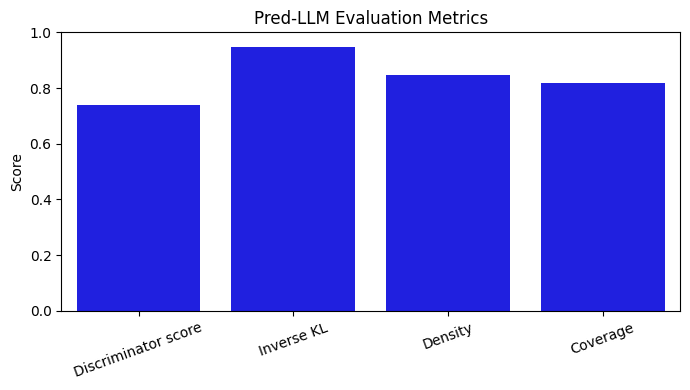

In [72]:

# Prepare data for plotting
df_results = pd.DataFrame(list(results.items()), columns=["Metric", "Pred-LLM"])

plt.figure(figsize=(7, 4))
sns.barplot(data=df_results, x="Metric", y="Pred-LLM", color="blue")
plt.title("Pred-LLM Evaluation Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()